# Modelo de Clasificación mediante Regresión Logística Multinomial para la predicción de niveles de TCH y Sacarosa en la industria azucarera

Este cuaderno tiene como objetivo desarrollar un modelo de clasificación basado en regresión logística multinomial para predecir los niveles de productividad de la caña de azúcar, específicamente el TCH (Toneladas de Caña por Hectárea) y el contenido de sacarosa.

Para ello, se utilizan datos históricos suministrados por el Ingenio Providencia, los cuales contienen información agronómica y de manejo del cultivo. Las variables continuas de interés (TCH y sacarosa) son transformadas en categorías (Bajo, Medio y Alto), permitiendo abordar el problema como una tarea de clasificación multiclase.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score
)

import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.preprocessing import imputar_datos, create_target_classes
from src.evaluation import evaluar_modelo

# Definición de rutas base a los archivos de datos los Raw
RAW_DATA_PATH_1 = '../data/processed/datos_limpios_clasificacion_tch.csv'
RAW_DATA_PATH_2 = '../data/processed/datos_limpios_clasificacion_sacarosa.csv'

## 2. Carga y Exploración Inicial de Datos

In [2]:
data_tch = pd.read_csv(RAW_DATA_PATH_1)
data_sac = pd.read_csv(RAW_DATA_PATH_2)

A continuación se cargan los datasets generados en el EDA que ya estan limpios, el cual contiene información histórica sobre variables escogidas anteriormente segun el nivel de influencia que tiene la variable para las predicciones.

## 3. Creación de clases para variables objetivo (TCH y sacarosa)

Para facilitar el modelado de clasificación, las variables continuas TCH y sacarosa se discretizaron en tres clases: Bajo, Medio y Alto.

In [3]:
map_clases = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

data_tch["TCH_clase"] = data_tch["Clase_TCH"].map(map_clases)
data_sac["sacarosa_clase"] = data_sac["Clase_Sacarosa"].map(map_clases)

## 4. Definición de las variables predictoras

En esta sección se seleccionan las variables predictoras que serán utilizadas por el modelo. La elección se basa en su relevancia agronómica y en su posible relación con el rendimiento y la calidad del cultivo de caña de azúcar.

Se incluyen variables asociadas al desarrollo del cultivo, condiciones climáticas, manejo agronómico y características del lote, ya que estas pueden influir tanto en el TCH como en el contenido de sacarosa.

In [4]:
features = [
    "dosismad",
    "semsmad",
    "edad",
    "cortes",
    "me",
    "vejez",
    "lluvias",
    "pct_diatrea"
]

Las variables seleccionadas permiten representar distintos factores que afectan el comportamiento del cultivo. Por ejemplo, `edad`, `cortes` y `vejez` reflejan el estado de desarrollo de la caña; `lluvias` captura condiciones climáticas; `dosismad` y `semsmad` representan manejo agronómico.

## 5. Modelado y Análisis para la Predicción de TCH

### 5.1. Definición de Características (X) y Variable Objetivo (y) para TCH

Se seleccionan las columnas que se utilizarán como características (`features`) para el modelo y se define `TCH_clase` como la variable objetivo (`y`). Posteriormente, los datos se dividen en conjuntos de entrenamiento y prueba utilizando `train_test_split` con una proporción del 80% para entrenamiento y 20% para prueba. `stratify=y` asegura que la distribución de las clases de la variable objetivo sea similar en ambos conjuntos.

In [5]:
X = data_tch[features]
y = data_tch["TCH_clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

El conjunto de prueba se separa desde el inicio y se reserva exclusivamente para la evaluación final del modelo. Esto garantiza que el modelo no tenga acceso a estos datos durante el entrenamiento, permitiendo medir de forma más realista su capacidad de generalización ante datos nuevos.

### 5.2. Preprocesamiento de Datos: Transformadores Numéricos y Categóricos

Esta sección define los pasos de preprocesamiento para las características numéricas y categóricas. Se utilizan `SimpleImputer` para manejar valores faltantes y `StandardScaler` para escalar características numéricas, y `OneHotEncoder` para convertir características categóricas en un formato numérico adecuado para el modelo.

In [6]:
numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numericas),
    ("cat", categorical_transformer, categoricas)
])

Este enfoque permite integrar el preprocesamiento dentro del pipeline del modelo, evitando fugas de información (data leakage) y asegurando que las transformaciones se apliquen correctamente tanto en entrenamiento como en prueba.

### 5.3. Creación del Pipeline del Modelo Base (Regresión Logística)

Se construye un `Pipeline` que encadena el preprocesamiento definido anteriormente (`preprocessor`) con un modelo de `LogisticRegression`. Se configuran algunos parámetros del modelo como `multi_class`, `solver` y `max_iter`.

In [7]:
pipe_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="saga",
        max_iter=5000
    ))
])

Se utiliza el solver `saga`, ya que permite trabajar con regularización L1 y L2 en problemas multiclase. Además, se incrementa el número de iteraciones (`max_iter`) para asegurar la convergencia del modelo.

### 5.4. Configuración de la Búsqueda de Hiperparámetros con GridSearchCV

Se define una estrategia de validación cruzada (`StratifiedKFold`) para asegurar una representación equitativa de las clases en cada pliegue. También se especifica una cuadrícula de hiperparámetros (`param_grid`) para el modelo de Regresión Logística, que incluye diferentes valores para la regularización (`penalty`) y el parámetro de fuerza de regularización (`C`). Finalmente, se configura `GridSearchCV` para buscar la mejor combinación de hiperparámetros.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

La validación cruzada se aplica únicamente sobre el conjunto de entrenamiento, lo que permite seleccionar los mejores hiperparámetros sin sesgar la evaluación final del modelo.

### 5.5. Entrenamiento del Modelo y Selección de los Mejores Hiperparámetros para TCH

Se entrena el modelo utilizando `GridSearchCV` sobre el conjunto de entrenamiento (`X_train`, `y_train`). Después del entrenamiento, se muestran los mejores hiperparámetros encontrados y el mejor puntaje de F1 macro obtenido durante la validación cruzada.

Antes del entrenamiento, se analiza la distribución de las clases con el fin de identificar posibles desbalances que puedan afectar el desempeño del modelo.

In [9]:
print("Distribución de clases TCH:")
print(data_tch["TCH_clase"].value_counts(dropna=False))

Distribución de clases TCH:
TCH_clase
Alto     737
Bajo     728
Medio    722
Name: count, dtype: int64


Como podemos ver, las clases del TCH se encuentran lo suficientemente balanceda, lo cual ayudara esto a que el modelo tenga un mejor comportamiento.

A continuación, se procede al entrenamiento del modelo:

In [10]:
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

/Users/isabellacv/ProvidenciaCane-Harvest-Forecasting-ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isabellacv/ProvidenciaCane-Harvest-Forecasting-ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isabellacv/ProvidenciaCane-Harvest-Forecasting-ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_rat

Mejores hiperparámetros: {'model__C': 0.01, 'model__penalty': 'l2'}
Mejor score CV: 0.46391390705910085


/Users/isabellacv/ProvidenciaCane-Harvest-Forecasting-ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### 5.7. Evaluación del Modelo en el Conjunto de Prueba para TCH

Una vez seleccionado el mejor modelo, se realizan predicciones sobre el conjunto de prueba (`X_test`) y se evalúa su rendimiento utilizando métricas como la exactitud (Accuracy), el F1 Macro y un reporte de clasificación detallado.

In [11]:
y_pred = best_model.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred))
print("F1 Macro en test:", f1_score(y_test, y_pred, average="macro"))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))
print("\nReporte de clasificación en test:")
print(classification_report(y_test, y_pred))

Accuracy en test: 0.4315068493150685
F1 Macro en test: 0.4277968865448802
Cohen's Kappa: 0.14695346108721152

Reporte de clasificación en test:
              precision    recall  f1-score   support

        Alto       0.36      0.36      0.36       148
        Bajo       0.50      0.58      0.53       146
       Medio       0.42      0.36      0.39       144

    accuracy                           0.43       438
   macro avg       0.43      0.43      0.43       438
weighted avg       0.43      0.43      0.43       438




El modelo obtuvo un desempeño medio-bajo en la clasificación de `TCH_clase`, con un Accuracy de aproximadamente 0.4315 y un F1 macro de 0.4278. Estos resultados indican que la regresión logística logra capturar parcialmente la relación entre las variables predictoras y los niveles de TCH, pero presenta limitaciones para diferenciar correctamente las tres clases.

A partir del reporte de clasificación, se observa que la clase "Bajo" presenta el mejor desempeño, seguida de la clase "Medio". Por el contrario, la clase "Alto" presenta el desempeño más bajo, lo que evidencia mayores dificultades para identificar correctamente los registros de mayor rendimiento.

El índice de Cohen’s Kappa fue de aproximadamente 0.1470, lo cual indica un nivel de acuerdo bajo entre las predicciones del modelo y los valores reales. Esto sugiere que, aunque el modelo identifica algunos patrones en los datos, su capacidad de clasificación es limitada.

En conjunto, estos resultados indican que los niveles de TCH no están completamente separados en el espacio de características, lo cual limita el desempeño de un modelo lineal.

### 5.8. Visualización de la Matriz de Confusión para TCH

La matriz de confusión proporciona una representación visual del rendimiento del algoritmo de clasificación, mostrando el número de predicciones correctas e incorrectas para cada clase.

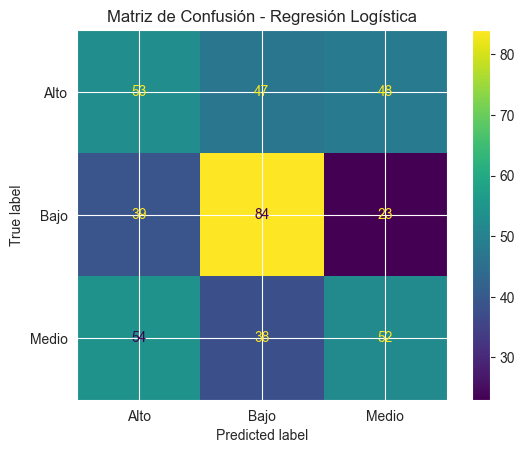

In [12]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

La matriz de confusión muestra que el modelo presenta mejor desempeño en la clase "Bajo", con un número mayor de predicciones correctas frente a las demás categorías. Sin embargo, las clases "Alto" y "Medio" presentan una tasa considerable de confusión con las otras clases, lo que evidencia dificultades del modelo para separar adecuadamente los niveles de desempeño.

### 5.9. Análisis de Importancia de Características para TCH

Se extraen los coeficientes del modelo de Regresión Logística para identificar qué características son más influyentes en la predicción de las clases de TCH. La importancia se calcula como el promedio del valor absoluto de los coeficientes para cada característica a través de las diferentes clases.

In [13]:
pre = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

feature_names = pre.get_feature_names_out()

coef_df = pd.DataFrame(
    model.coef_.T,
    index=feature_names,
    columns=model.classes_
)

importancia = coef_df.abs().mean(axis=1).sort_values(ascending=False)
importancia.head(15)

num__cortes         0.189512
num__edad           0.111231
num__pct_diatrea    0.106663
num__semsmad        0.079275
num__vejez          0.066840
num__me             0.043704
num__lluvias        0.025760
num__dosismad       0.021502
dtype: float64

Las variables con mayor importancia en el modelo fueron `cortes`, `edad`, `pct_diatrea`, `semsmad` y `vejez`. Esto es coherente con el comportamiento agronómico del cultivo de caña de azúcar, ya que el número de cortes y la edad del cultivo están directamente relacionados con el estado productivo de la plantación.

La variable `pct_diatrea` también presenta una influencia relevante, lo cual puede explicarse por el efecto que las plagas tienen sobre el desarrollo y la calidad del cultivo. Asimismo, variables asociadas a la maduración, como `semsmad` y `vejez`, aportan información importante para diferenciar los niveles de desempeño.

En este caso, la mejor configuración del modelo utilizó regularización L2, la cual no elimina variables, sino que reduce y estabiliza la magnitud de los coeficientes. Esto permite controlar la complejidad del modelo sin descartar completamente predictores.

En conjunto, los resultados muestran que el modelo captura relaciones coherentes con el conocimiento agronómico, lo cual favorece su interpretabilidad.

## 6. Modelado y Análisis para la Predicción de Sacarosa

### 6.1. Definición de Características (X) y Variable Objetivo (y) para Sacarosa

En esta sección se redefine la variable objetivo como `sacarosa_clase`, manteniendo el mismo conjunto de variables predictoras utilizado en el modelo de TCH. De esta manera, se asegura la comparabilidad entre ambos modelos.

Posteriormente, los datos se dividen en conjuntos de entrenamiento (80%) y prueba (20%) utilizando `train_test_split`, manteniendo la proporción de clases mediante `stratify=y`.

In [14]:
X_sacarosa = data_sac[features]
y_sacarosa = data_sac["sacarosa_clase"]

X_train_sacarosa, X_test_sacarosa, y_train_sacarosa, y_test_sacarosa = train_test_split(
    X_sacarosa,
    y_sacarosa,
    test_size=0.2,
    random_state=42,
    stratify=y_sacarosa
)

### 6.2. Re-entrenamiento del Modelo de Regresión Logística con Sacarosa

Se reentrena el modelo de regresión logística utilizando `GridSearchCV`, manteniendo la misma estructura de pipeline, validación cruzada y espacio de búsqueda de hiperparámetros. Esto permite evaluar si la configuración óptima encontrada para TCH también es adecuada para la predicción de sacarosa o si existen diferencias significativas.

In [15]:
grid_sacarosa = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

grid_sacarosa.fit(X_train_sacarosa, y_train_sacarosa)

best_model_sacarosa = grid_sacarosa.best_estimator_

print("Mejores hiperparámetros para Sacarosa:", grid_sacarosa.best_params_)
print("Mejor score CV para Sacarosa:", grid_sacarosa.best_score_)

/Users/isabellacv/ProvidenciaCane-Harvest-Forecasting-ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isabellacv/ProvidenciaCane-Harvest-Forecasting-ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isabellacv/ProvidenciaCane-Harvest-Forecasting-ML/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_rat

Mejores hiperparámetros para Sacarosa: {'model__C': 10, 'model__penalty': 'l1'}
Mejor score CV para Sacarosa: 0.45720021285558604


#### Análisis de los mejores hiperparámetros para sacarosa

Para la variable `sacarosa_clase`, la búsqueda de hiperparámetros identificó como mejor configuración una penalización `l1` con un valor de regularización `C = 10`. Esta combinación obtuvo un F1 macro de validación cruzada de aproximadamente **0.4572**, lo cual indica un desempeño moderado del modelo.

A diferencia del modelo para TCH, que obtuvo mejores resultados con regularización `l2` y un valor bajo de `C`, el modelo para sacarosa favoreció una regularización `l1` con un valor alto de `C`. Esto sugiere que la relación entre las variables predictoras y los niveles de sacarosa presenta una estructura diferente.

El valor alto de `C` implica una regularización más débil, permitiendo que el modelo conserve coeficientes de mayor magnitud. Además, la penalización `l1` puede reducir a cero la influencia de algunas variables, funcionando como un mecanismo de selección de predictores relevantes para la clasificación de sacarosa.

### 6.3. Evaluación del Modelo de Sacarosa en el Conjunto de Prueba

Se evalúa el rendimiento del modelo en el conjunto de prueba para `sacarosa_clase`.

In [16]:
y_pred_sacarosa = best_model_sacarosa.predict(X_test_sacarosa)

print("Accuracy en test (Sacarosa):", accuracy_score(y_test_sacarosa, y_pred_sacarosa))
print("F1 Macro en test (Sacarosa):", f1_score(y_test_sacarosa, y_pred_sacarosa, average="macro"))
print("Kappa de Cohen en test (Sacarosa):", cohen_kappa_score(y_test_sacarosa, y_pred_sacarosa))
print("\nReporte de clasificación en test (Sacarosa):")
print(classification_report(y_test_sacarosa, y_pred_sacarosa))

Accuracy en test (Sacarosa): 0.4657534246575342
F1 Macro en test (Sacarosa): 0.4471833592419869
Kappa de Cohen en test (Sacarosa): 0.1971864082841165

Reporte de clasificación en test (Sacarosa):
              precision    recall  f1-score   support

        Alto       0.36      0.22      0.27       142
        Bajo       0.44      0.58      0.50       143
       Medio       0.55      0.59      0.57       153

    accuracy                           0.47       438
   macro avg       0.45      0.46      0.45       438
weighted avg       0.45      0.47      0.45       438



El modelo obtuvo un desempeño moderado en la clasificación de `sacarosa_clase`, con un Accuracy de aproximadamente 0.4658 y un F1 macro de 0.4472. Estos resultados son ligeramente superiores a los obtenidos para TCH, lo que sugiere que los niveles de sacarosa presentan una mejor separabilidad entre clases.

A partir del reporte de clasificación, se observa que la clase "Medio" presenta el mejor desempeño, con un F1-score de 0.57, seguida de la clase "Bajo" con 0.50. Por el contrario, la clase "Alto" presenta el desempeño más bajo, con un F1-score de 0.27, lo que evidencia una mayor dificultad para identificar correctamente los registros con alto contenido de sacarosa.

El índice de Cohen’s Kappa fue de aproximadamente 0.1972, lo cual indica un nivel de acuerdo bajo a medio entre las predicciones del modelo y los valores reales. 

En conjunto, estos resultados sugieren que los niveles de sacarosa no están completamente separados en el espacio de características, aunque el modelo presenta una ligera mejora respecto a la predicción de TCH.

### 6.4. Visualización de la Matriz de Confusión para Sacarosa

La matriz de confusión para `sacarosa_clase` nos ayuda a entender visualmente dónde el modelo acierta y dónde se equivoca.

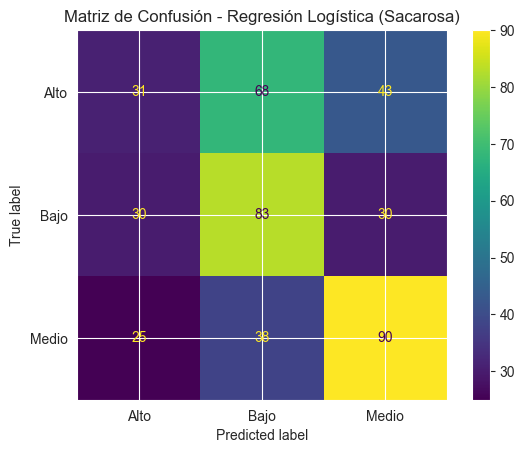

In [17]:
ConfusionMatrixDisplay.from_estimator(best_model_sacarosa, X_test_sacarosa, y_test_sacarosa)
plt.title("Matriz de Confusión - Regresión Logística (Sacarosa)")
plt.show()

Al igual que con TCH, la matriz de confusión para sacarosa revela las fortalezas y debilidades del modelo. Se observa que la clase "Medio" presenta el mejor desempeño, con un mayor número de predicciones correctas, seguida de la clase "Bajo". Por el contrario, la clase "Alto" presenta mayores dificultades de clasificación, siendo frecuentemente confundida con la clase "Bajo".

Este comportamiento indica que, aunque el modelo logra identificar adecuadamente algunos patrones en los niveles intermedios de sacarosa, aún existe confusión entre las categorías, especialmente en los extremos. Comparar este patrón con la matriz de TCH permite ver que la sacarosa presenta una ligera mejora en la separabilidad de sus clases, aunque el problema sigue siendo complejo.

### 6.5. Análisis de Importancia de Características para Sacarosa

Se extraen los coeficientes del modelo de Regresión Logística para identificar las características más influyentes en la predicción de las clases de sacarosa.

In [18]:
pre_sacarosa = best_model_sacarosa.named_steps["preprocessor"]
model_sacarosa = best_model_sacarosa.named_steps["model"]

feature_names_sacarosa = pre_sacarosa.get_feature_names_out()

coef_df_sacarosa = pd.DataFrame(
    model_sacarosa.coef_.T,
    index=feature_names_sacarosa,
    columns=model_sacarosa.classes_
)

importancia_sacarosa = coef_df_sacarosa.abs().mean(axis=1).sort_values(ascending=False)
importancia_sacarosa.head(15)

num__semsmad        0.250897
num__me             0.233197
num__lluvias        0.198168
num__edad           0.131786
num__pct_diatrea    0.066524
num__vejez          0.036688
num__cortes         0.020316
num__dosismad       0.014165
dtype: float64

Las variables con mayor importancia en la predicción de `sacarosa_clase` fueron `semsmad`, `me`, `lluvias` y `edad`. Esto sugiere que los factores asociados a la maduración, las condiciones hídricas y el estado del cultivo tienen un papel relevante en la clasificación de los niveles de sacarosa.

La variable `semsmad` presenta la mayor importancia, lo cual es coherente con el comportamiento fisiológico de la caña, ya que el proceso de maduración influye directamente en la acumulación de sacarosa. Asimismo, `lluvias` puede afectar la concentración de azúcar, especialmente en etapas cercanas a la cosecha.

En conjunto, estos resultados muestran que el modelo identifica variables coherentes con el conocimiento agronómico y con los factores que influyen en la calidad de la caña.

Este análisis nos muestra qué características son más relevantes para predecir los niveles de sacarosa. Al comparar esta lista con la importancia de características para TCH, podemos identificar factores que influyen de manera similar en ambas productividades o aquellos que tienen un impacto diferenciado. Esto puede proporcionar información valiosa sobre la agronomía del cultivo y ayudar a futuras mejoras.

In [19]:
resumen = pd.DataFrame({
    "Objetivo": ["TCH", "Sacarosa"],
    "Mejor_CV_F1_macro": [grid.best_score_, grid_sacarosa.best_score_],
    "Test_Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_sacarosa, y_pred_sacarosa)
    ],
    "Test_F1_macro": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test_sacarosa, y_pred_sacarosa, average="macro")
    ]
})

resumen

,Objetivo,Mejor_CV_F1_macro,Test_Accuracy,Test_F1_macro
0,TCH,0.463914,0.431507,0.427797
1,Sacarosa,0.457200,0.465753,0.447183


La comparación entre ambos modelos permite identificar cuál variable objetivo es más fácil de clasificar utilizando regresión logística. En este caso, el modelo para `sacarosa_clase` obtuvo un mejor desempeño en el conjunto de prueba, con un Accuracy de 0.4658 y un F1 macro de 0.4472, frente a un Accuracy de 0.4315 y un F1 macro de 0.4278 para `TCH_clase`.

Esto sugiere que, con las variables disponibles, los niveles de sacarosa presentan una ligera mayor separabilidad que los niveles de TCH. Sin embargo, los resultados siguen siendo moderados en ambos casos, lo que indica que la regresión logística solo logra capturar parcialmente la relación entre las variables predictoras y las clases objetivo.

## 7. Análisis exploratorio con PCA (visualización de los datos)
Con el objetivo de analizar que tan separadas estan las clases en el espacio de características, se aplicó Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del conjunto de datos a dos componentes.

Esta visualización permite observar la distribución de las clases en un espacio bidimensional y evaluar si existen patrones claros de separación.

In [20]:
from sklearn.decomposition import PCA

X_transformed = preprocessor.fit_transform(X)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [22]:
model_2d = LogisticRegression(max_iter=5000)
model_2d.fit(X_pca, y_encoded)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

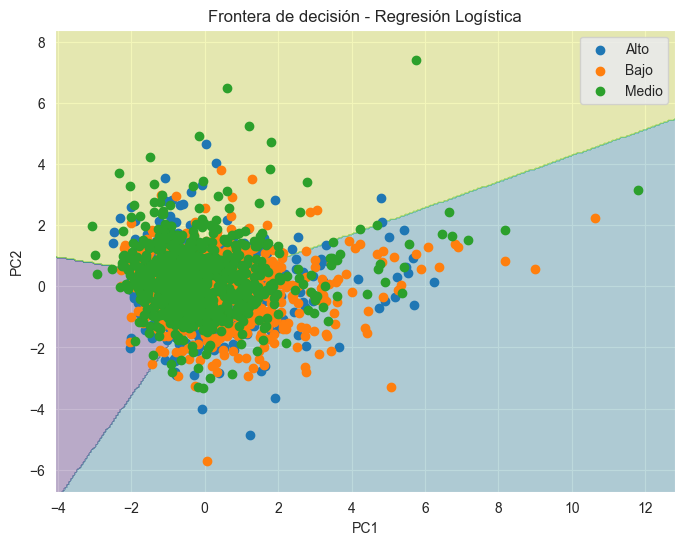

In [24]:
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

for i, clase in enumerate(le.classes_):
    mask = (y_encoded == i)
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=clase
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Frontera de decisión - Regresión Logística")
plt.legend()
plt.grid(True)
plt.show()

Como podemos observar, los resultados muestran un alto grado de solapamiento entre las clases, lo cual sugiere que el problema no es linealmente separable. Esto explica el desempeño del modelo de regresión logística, el cual se basa en fronteras de decisión lineales.

## 8. Conclusiones

La regresión logística multinomial permitió construir un modelo base para clasificar niveles de TCH y sacarosa a partir de variables agronómicas y de manejo. La estrategia de validación rigurosa, basada en una partición hold-out 80/20 y validación cruzada estratificada de 5 pliegues sobre el conjunto de entrenamiento, permitió seleccionar hiperparámetros de forma robusta y reducir el riesgo de sobreajuste.

En el caso de TCH, el modelo mostró un desempeño moderado-bajo, con un F1 macro de 0.4278. La clase "Bajo" presentó el mejor rendimiento, mientras que la clase "Alto" fue la más difícil de clasificar. Esto sugiere que los niveles de TCH no están completamente separados en el espacio de características.

Para sacarosa, el modelo obtuvo un desempeño ligeramente superior, con un F1 macro de 0.4472. Esto indica que, con las variables disponibles, los niveles de sacarosa presentan una separación un poco más clara que los niveles de TCH, aunque el desempeño general sigue siendo bajo.

El análisis mediante PCA confirmó que las clases no son completamente separables, evidenciando un alto grado de solapamiento. Esto explica las limitaciones del modelo de regresión logística, el cual se basa en fronteras de decisión lineales.

Las variables más influyentes identificadas por el modelo fueron coherentes con el conocimiento agronómico del cultivo. Para TCH destacaron variables como `cortes`, `edad`, `pct_diatrea` y `semsmad`, asociadas al estado productivo del cultivo, sanidad y maduración. Para sacarosa, las variables más relevantes fueron `semsmad`, `me`, `lluvias` y `edad`, relacionadas con la maduración, calidad del material cosechado y condiciones hídricas.

En conjunto, los resultados muestran que la regresión logística es útil como modelo base e interpretable, pero su desempeño limitado sugiere que la estructura del problema podría requerir modelos no lineales capaces de capturar relaciones más complejas entre las variables.